##Setup and Data Download
This initial cell remains the same. It sets up the environment, downloads the dataset, and sets a random seed for reproducibility.

In [1]:
!pip install -q albumentations

import torch
import os
import random
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Set a fixed random seed for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# === DIRECT KAGGLE CREDENTIALS ===
os.environ['KAGGLE_USERNAME'] = 'asd147'
os.environ['KAGGLE_KEY']     = '6a95e405001115800e2e18044513a965'
# ===================================


# Always download
!kaggle datasets download -d andrewmvd/car-plate-detection
# Unzip quietly and with force-overwrite
!unzip -q -o car-plate-detection.zip -d ./data
!rm -f car-plate-detection.zip

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/car-plate-detection
License(s): CC0-1.0
100% 203M/203M [00:01<00:00, 199MB/s]

Using device: cuda


##Dataset and Optimized Augmentations (Modified)
We increase the image size and use a more refined augmentation strategy. We keep HorizontalFlip as it's very effective but reduce the intensity of other augmentations.

In [2]:
# Define a refined set of augmentations
from torch.utils.data import Dataset

def get_transform(train):
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
            A.GaussianBlur(blur_limit=(3, 5), p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))
    else:
        return A.Compose([
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

# Re-use the Albumentations Dataset class from the previous step
class PlateAlbumentationsDataset(Dataset):
    def __init__(self, data_dir, image_files, width, height, transforms=None):
        self.transforms = transforms
        self.data_dir = data_dir
        self.height = height
        self.width = width
        self.image_files = image_files

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.data_dir, 'images', img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.width, self.height), interpolation=cv2.INTER_LANCZOS4) # Use a high-quality resize

        ann_name = img_name.replace('.png', '.xml')
        ann_path = os.path.join(self.data_dir, 'annotations', ann_name)
        tree = ET.parse(ann_path)
        root = tree.getroot()

        orig_w = int(root.find('size').find('width').text)
        orig_h = int(root.find('size').find('height').text)
        bndbox = root.find('object').find('bndbox')

        xmin = (float(bndbox.find('xmin').text) / orig_w) * self.width
        ymin = (float(bndbox.find('ymin').text) / orig_h) * self.height
        xmax = (float(bndbox.find('xmax').text) / orig_w) * self.width
        ymax = (float(bndbox.find('ymax').text) / orig_h) * self.height

        boxes = [[xmin, ymin, xmax, ymax]]
        labels = [1]

        target = {'boxes': boxes, 'labels': labels}

        if self.transforms:
            augmented = self.transforms(image=image, bboxes=target['boxes'], labels=target['labels'])
            image = augmented['image']
            target['boxes'] = torch.as_tensor(augmented['bboxes'], dtype=torch.float32) if augmented['bboxes'] else torch.zeros((0, 4), dtype=torch.float32)
            target['labels'] = torch.as_tensor(augmented['labels'], dtype=torch.int64)

        return image, target

    def __len__(self):
        return len(self.image_files)

def collate_fn(batch):
    return tuple(zip(*batch))

##DataLoaders with Increased Resolution (Modified)
We instantiate the datasets with the new 512x512 resolution. Due to the larger image and model size, we must reduce the batch size to avoid running out of GPU memory.

In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import xml.etree.ElementTree as ET

# NEW: Increased image resolution
IMG_WIDTH, IMG_HEIGHT = 512, 512
data_dir = './data'

all_image_files = sorted([f for f in os.listdir(os.path.join(data_dir, 'images')) if f.endswith('.png')])
train_files, val_files = train_test_split(all_image_files, test_size=0.2, random_state=42)

train_dataset = PlateAlbumentationsDataset(data_dir, train_files, IMG_WIDTH, IMG_HEIGHT, get_transform(train=True))
val_dataset = PlateAlbumentationsDataset(data_dir, val_files, IMG_WIDTH, IMG_HEIGHT, get_transform(train=False))

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# NEW: Reduced batch size to accommodate larger model and images
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=6, shuffle=False, collate_fn=collate_fn)

Training set size: 346
Validation set size: 87


/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


##Model Architecture: Back to ResNet50 (Modified)
We bring back the fasterrcnn_resnet50_fpn model that gave us our best score.

In [4]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def create_best_model():
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    num_classes = 2 # 1 class (plate) + background
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = create_best_model()
model = model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:03<00:00, 53.9MB/s]


##Final Optimized Training Loop (Modified)
We will train for more epochs (25) with a finely tuned learning rate and scheduler.

In [5]:
import torch.optim as optim
from tqdm import tqdm

# NEW: Longer training and tuned LR
num_epochs = 25
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.003, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0.00001)

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        valid_batch = [(img, tgt) for img, tgt in zip(images, targets) if len(tgt['boxes']) > 0]
        if not valid_batch: continue
        images, targets = collate_fn(valid_batch)

        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_train_loss += losses.item()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, LR: {lr_scheduler.get_last_lr()[0]:.6f}")
    lr_scheduler.step()

print("\nFinished Training. Now evaluating for the peak IoU score.")

Epoch 1/25 [Train]: 100%|██████████| 58/58 [01:31<00:00,  1.58s/it]


Epoch 1/25, Train Loss: 0.2120, LR: 0.003000


Epoch 2/25 [Train]: 100%|██████████| 58/58 [01:40<00:00,  1.73s/it]


Epoch 2/25, Train Loss: 0.1146, LR: 0.002988


Epoch 3/25 [Train]: 100%|██████████| 58/58 [01:40<00:00,  1.73s/it]


...

Epoch 23/25, Train Loss: 0.0505, LR: 0.000115


Epoch 24/25 [Train]: 100%|██████████| 58/58 [01:40<00:00,  1.73s/it]


Epoch 24/25, Train Loss: 0.0496, LR: 0.000057


Epoch 25/25 [Train]: 100%|██████████| 58/58 [01:41<00:00,  1.74s/it]

Epoch 25/25, Train Loss: 0.0507, LR: 0.000022

Finished Training. Now evaluating for the peak IoU score.


##Performance Evaluation with IoU (Modified)
We need a new evaluation function because the model output format is different now. It gives a dictionary with boxes, labels, and scores.

In [6]:
def calculate_iou_detection(pred_boxes, true_boxes):
    if pred_boxes.shape[0] == 0 or true_boxes.shape[0] == 0: return torch.tensor(0.0)
    pred_boxes, true_boxes = pred_boxes.view(-1, 4), true_boxes.view(-1, 4)
    inter_xmin = torch.max(pred_boxes[:, 0].unsqueeze(1), true_boxes[:, 0])
    inter_ymin = torch.max(pred_boxes[:, 1].unsqueeze(1), true_boxes[:, 1])
    inter_xmax = torch.min(pred_boxes[:, 2].unsqueeze(1), true_boxes[:, 2])
    inter_ymax = torch.min(pred_boxes[:, 3].unsqueeze(1), true_boxes[:, 3])
    inter_area = torch.clamp(inter_xmax - inter_xmin, min=0) * torch.clamp(inter_ymax - inter_ymin, min=0)
    pred_area = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
    true_area = (true_boxes[:, 2] - true_boxes[:, 0]) * (true_boxes[:, 3] - true_boxes[:, 1])
    union_area = pred_area.unsqueeze(1) + true_area - inter_area
    iou = inter_area / (union_area + 1e-6)
    return iou.max(dim=1)[0]

model.eval()
total_iou = 0.0
total_images = 0
with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = list(img.to(device) for img in images)
        outputs = model(images)
        for i, output in enumerate(outputs):
            pred_boxes = output['boxes']
            true_boxes = targets[i]['boxes'].to(device)
            if len(pred_boxes) > 0:
                best_pred_box = pred_boxes[0].unsqueeze(0)
                iou_score = calculate_iou_detection(best_pred_box, true_boxes)
                total_iou += iou_score.sum().item()
        total_images += len(images)
avg_iou = total_iou / total_images
print(f"\nFinal Optimized Average IoU on the validation set: {avg_iou:.4f}")

Evaluating: 100%|██████████| 15/15 [00:10<00:00,  1.38it/s]


Final Optimized Average IoU on the validation set: 0.7671


##Visualizing Predictions (Modified)
The visualization function is updated to handle the new model's output format.

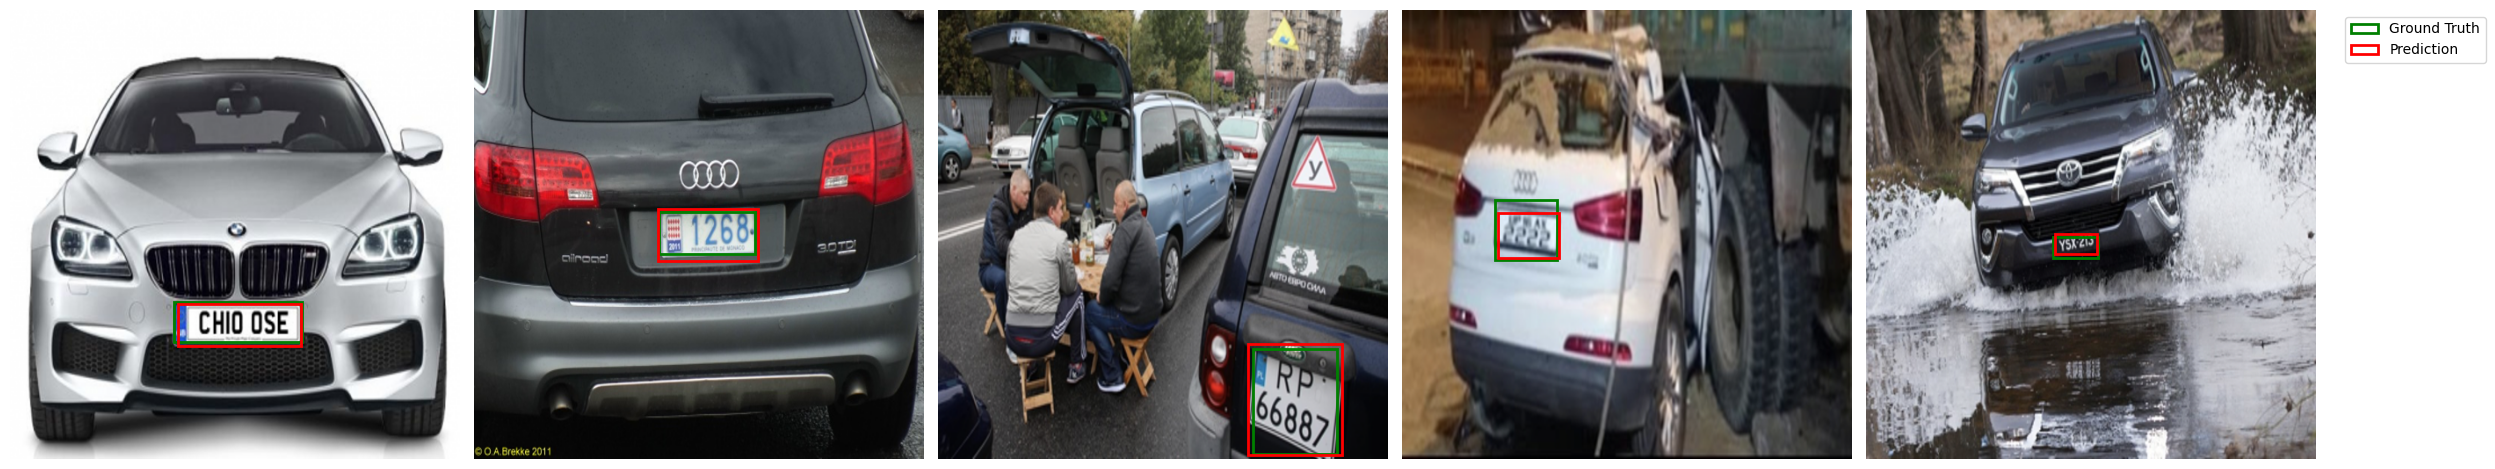

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_detection_predictions(dataset, model, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(25, 5))
    indices = random.sample(range(len(dataset)), num_samples)
    model.eval()
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, target = dataset[idx]
            img_file = dataset.image_files[idx]
            original_image = Image.open(os.path.join(dataset.data_dir, 'images', img_file)).convert("RGB").resize((dataset.width, dataset.height))
            prediction = model([img_tensor.to(device)])[0]
            ax = axes[i]; ax.imshow(original_image); ax.axis('off')
            true_box = target['boxes'][0]
            gt_rect = patches.Rectangle((true_box[0], true_box[1]), true_box[2]-true_box[0], true_box[3]-true_box[1], linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
            ax.add_patch(gt_rect)
            if len(prediction['boxes']) > 0:
                best_pred_box = prediction['boxes'][0].cpu()
                pred_rect = patches.Rectangle((best_pred_box[0], best_pred_box[1]), best_pred_box[2]-best_pred_box[0], best_pred_box[3]-best_pred_box[1], linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
                ax.add_patch(pred_rect)
    plt.legend(handles=[gt_rect, pred_rect], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

visualize_detection_predictions(val_dataset, model)